# 4-3 공개 이미지 데이터셋의 사용

본 노트북은 본문 4-3 절의 코드 예제([코드 4-18] ~ [코드 4-24])를 절 흐름 그대로 모은 것이다. torchvision 내장 MNIST 데이터셋으로 다층 퍼셉트론 숫자 분류기를 만든다.

다루는 내용
- `datasets.MNIST` 내장 데이터셋 로드
- `Resize` / `ToTensor` / `Normalize` 이미지 변환과 `transforms.Compose`
- 50,000 / 10,000 훈련·검증 분리, 배치 크기 100 데이터로더
- 다층 퍼셉트론 숫자 분류기 모델 정의·학습·평가

> MNIST 자동 다운로드 데이터는 공개 저장소 규약(§13.9)에 따라 `root='../../downloads'` 로 받는다. 본문 경로는 `'../data'` 이며, 이 차이는 `_book` 에 기록한다.

## 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)

torchvision 은 기본 의존성으로 README 에서 안내한다. 별도 설치가 필요하면 아래를 사용한다.

In [1]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# !pip install -q torchvision

## 라이브러리 import 와 시드 고정

In [2]:
# 참고 - 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

In [3]:
# 참고 - 라이브러리 import 와 시드 고정
import copy
import random
import time

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

CUDA를 사용합니다.


## [코드 4-18] 파이토치 내장 MNIST 데이터셋으로 `Dataset` 객체 생성

`datasets.MNIST` 로 내장 데이터셋을 불러온다. `transform=None` 이면 원본은 Pillow 객체와 정답 정수의 튜플이다.

In [4]:
# 코드 4-19 - 파이토치 내장 MNIST 데이터셋으로 Dataset 객체 생성

# data_root: 내려받은 데이터셋을 저장할 디렉터리 경로
data_root = '../../downloads'
train_set = datasets.MNIST(
    root=data_root, train=True, download=True, transform=None,
)
test_set = datasets.MNIST(
    root=data_root, train=False, download=True, transform=None,
)

# 훈련 데이터셋의 첫 번째 샘플
print(train_set[0])              # PIL.Image.Image 객체(Pillow 객체)와 정답의 튜플

(<PIL.Image.Image image mode=L size=28x28 at 0x72A556B1FC50>, 5)


## 참고 - [그림 4-2] 대응: MNIST 샘플 이미지 격자

본문 [그림 4-2] 와 같이 0부터 9까지 숫자별 샘플 이미지를 하나씩 격자로 표시한다.

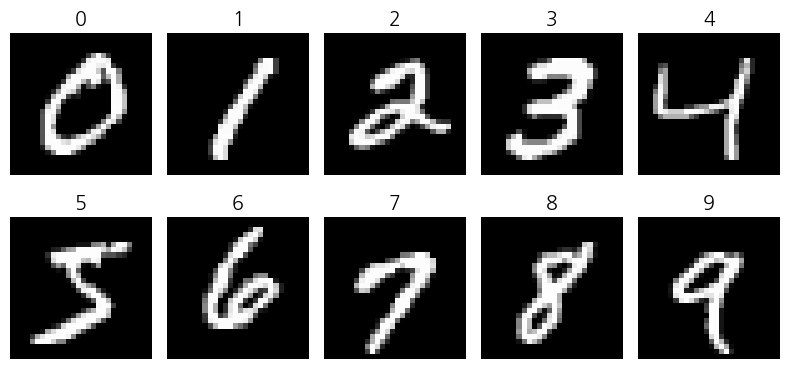

In [5]:
# [그림 4-2] - MNIST 샘플 이미지 격자 (0~9 하나씩)

targets = train_set.targets                      # 전체 정답 텐서 (60000,)
imgs, descs = [], []
for digit in range(10):
    idx = int((targets == digit).nonzero()[0])   # 각 숫자가 처음 등장하는 위치
    imgs.append(train_set[idx][0])
    descs.append(str(digit))
viz.plot_images(imgs, descs, images_per_row=5)

## [코드 4-19] `Resize`, `ToTensor` 와 `Normalize` 를 사용해 Pillow 객체를 변환

크기 변환·텐서 변환·표준화 변환 객체를 각각 만들어 순서대로 적용한다. `ToTensor` 는 (C, H, W) 텐서로 바꾸며 픽셀값을 0~1 로 정규화하고, `Normalize(0.5, 0.5)` 는 결과를 -1~1 로 표준화한다.

In [6]:
# 코드 4-20 - Resize, ToTensor 와 Normalize 를 사용해 Pillow 객체를 변환

# 데이터 변환 객체
resize_20x20 = transforms.Resize((20, 20))      # 크기 변환 객체: 목표 크기는 튜플로 지정
to_tensor = transforms.ToTensor()               # 텐서 변환 객체
normalize = transforms.Normalize(0.5, 0.5)      # 표준화 변환 객체(평균과 표준편차 각 0.5)
# 3 채널 컬러 이미지는 다음과 같이 채널별 평균, 표준편차를 지정
# transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

# 데이터 변환 객체로 데이터 변환
sample_image = train_set[0][0]                  # 샘플 이미지
resized_image = resize_20x20(sample_image)      # 크기 변환 (Pillow 객체)
sample_tensor = to_tensor(resized_image)        # 이미지를 텐서로 변환
sample_normalized = normalize(sample_tensor)    # 표준화된 텐서로 변환

# 변환 결과 확인
min_value = torch.min(sample_normalized).item()
max_value = torch.max(sample_normalized).item()
print(f'표준화 텐서의 형태: {sample_normalized.shape}')        
print(f'표준화 텐서 요솟값의 범위: {min_value} ~ {max_value}') 

표준화 텐서의 형태: torch.Size([1, 20, 20])
표준화 텐서 요솟값의 범위: -1.0 ~ 0.9843137264251709


## [코드 4-20] `transforms.Compose` 를 사용해 데이터 변환 객체와 데이터셋 생성

`transforms.Compose` 로 변환 객체들을 묶으면 리스트 순서대로 변환을 실행한다. `nn.Flatten` 처럼 하나의 값을 받아 변환해 반환하는 객체도 함께 묶을 수 있다.

In [7]:
# 코드 4-21 - transforms.Compose 를 사용해 데이터 변환 객체와 데이터셋 생성

# transforms.Compose 로 묶어서 데이터 변환 객체 생성
transform_chain = transforms.Compose([
    transforms.Resize((20, 20)),            # 28x28 이미지를 20x20 이미지로 변환
    transforms.ToTensor(),                  # 0~1 정규화된 (1, 20, 20) 텐서로 변환
    transforms.Normalize((0.5,), (0.5,)),   # 평균 0.5, 표준편차 0.5를 기준으로 표준화
    nn.Flatten(start_dim=0)                # 평탄화: (1, 20, 20) -> (400,)
])

# 데이터 변환 객체를 transform 인자로 전달해 훈련 데이터셋 생성
train_set = datasets.MNIST(
    root=data_root, train=True, download=True,
    transform=transform_chain
)

# 변환 결과 확인
print('훈련 데이터셋의 첫 번째 샘플 텐서')
image_tensor = train_set[0][0]
label = train_set[0][1]
print(f'이미지 텐서의 형태: {image_tensor.shape}')
print(f'레이블의 값과 자료형: {label}, {type(label)}')

훈련 데이터셋의 첫 번째 샘플 텐서
이미지 텐서의 형태: torch.Size([400])
레이블의 값과 자료형: 5, <class 'int'>


## [코드 4-21] 숫자 분류기 모델을 만들기 위한 데이터 준비 과정

[코드 4-20] 의 변환에서 크기 변환(`Resize`)만 제외해 (784,) 텐서를 만든다. 훈련 데이터셋 60,000 개를 50,000(훈련) + 10,000(검증) 으로 나누고, 배치 크기 100 의 데이터로더를 만든다.

In [8]:
# 코드 4-22 - 숫자 분류기 모델을 만들기 위한 데이터 준비 과정

# Resize를 제외한 데이터 변환 객체 생성
transform_chain = transforms.Compose([
    transforms.ToTensor(),                  # 0~1 정규화된 (1, 28, 28) 텐서로 변환
    transforms.Normalize((0.5,), (0.5,)),   # 평균 0.5, 표준편차 0.5로 표준화
    nn.Flatten(start_dim=0),                # 평탄화: (1, 28, 28) -> (784,)
])

# 데이터셋 생성
train_set = datasets.MNIST(
    root=data_root, train=True, download=True,
    transform=transform_chain
)
test_set = datasets.MNIST(
    root=data_root, train=False, download=True,
    transform=transform_chain
)

# train_set을 50,000 개의 훈련 데이터셋과 10,000 개의 검증 데이터셋으로 분리
train_set, valid_set = random_split(
    train_set,
    [50000, 10000],                         # 훈련 데이터셋과 검증 데이터셋의 샘플 수
    generator=torch.Generator().manual_seed(SEED),
)

# 데이터로더 생성
BATCH_SIZE = 100                            # 배치 크기
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'훈련 샘플 수: {len(train_set)}')
print(f'검증 샘플 수: {len(valid_set)}')
print(f'평가 샘플 수: {len(test_set)}')
print(f'훈련 미니배치 수: {len(train_loader)}')

훈련 샘플 수: 50000
검증 샘플 수: 10000
평가 샘플 수: 10000
훈련 미니배치 수: 500


## [코드 4-22] 다층 퍼셉트론 숫자 분류기 모델을 정의하고 모델 객체 생성

입력 (784,), 출력 (10,) 의 다층 퍼셉트론이다. 뉴런 256 개와 128 개인 은닉층 두 개를 둔다.

In [9]:
# 코드 4-23 - 다층 퍼셉트론 숫자 분류기 모델을 정의하고 모델 객체 생성

# MNIST 데이터셋을 분류하는 다층 퍼셉트론 모델 클래스
class MNISTMLPClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),        # 첫 번째 은닉층: (B, 784) -> (B, 256)
            nn.ReLU(),
            nn.Linear(256, 128),        # 두 번째 은닉층: (B, 256) -> (B, 128)
            nn.ReLU(),
            nn.Linear(128, 10),         # 출력층: (B, 128) -> (B, 10)
        )

    def forward(self, x):
        return self.net(x)

model = MNISTMLPClassifier()        # 모델 객체 생성
print(model)

MNISTMLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 참고 - 4-2 절의 미니배치 + 조기 종료 학습 함수 재정의

본문은 4-2 절의 학습 함수([코드 4-16]) 를 그대로 재사용한다고 설명한다. 노트북은 자기 완결성을 위해 같은 함수를 다시 정의한다.

In [ ]:
# 참고 - 학습 함수는 4-2절의 미니배치, 조기 종료 학습 함수를 그대로 사용

# 1 에포크의 모델 파라미터를 최적화하는 학습 함수
def train_batch(model, X_train, Y_train, criterion, optimizer):    
    model.train()                                       # 학습 모드
    Y_train_pred = model(X_train)
    train_loss = criterion(Y_train_pred, Y_train)       # 훈련 손실 계산
    optimizer.zero_grad()
    train_loss.backward()                               # 훈련 손실로 역전파
    optimizer.step()
    return train_loss.item()

# 모델 성능을 검증하는 평가 함수
def validate(model, X_valid, Y_valid, criterion):
    model.eval()                                        # 평가 모드
    with torch.no_grad():
        Y_valid_pred = model(X_valid)
        valid_loss = criterion(Y_valid_pred, Y_valid)   # 검증 손실 계산
    return valid_loss.item()

# 조기 종료를 적용한 학습 루프 함수
def train_with_early_stopping(model,
                              train_loader, valid_loader,
                              criterion, optimizer, epochs, patience):
    # 표준 학습 로거 생성
    log = common.EpochLogger(epochs, columns=('훈련 손실', '검증 손실'),
                             formats=('{:.4f}', '{:.4f}'))
    # 조기 종료를 위한 변수 초기화
    best_valid_loss = float('inf')  # 지금까지의 최소 검증 손실: 충분히 큰 값으로 초기화
    best_model_params = None        # 검증 손실이 최소일 때의 파라미터를 저장할 딕셔너리
    patience_counter = 0            # 참을성 카운터
    best_epoch = 0                  # 최적 에포크: 검증 손실이 최소일 때의 에포크

    for epoch in range(1, epochs + 1):
        # 훈련, 검증 손실의 가중합과 훈련, 검증 샘플 수 누적 변수: 에포크마다 초기화
        train_loss_sum, valid_loss_sum = 0, 0
        train_sample_size, valid_sample_size = 0, 0

        # 최적화 단계: train_batch()는 train_epoch()와 같지만 최적화 단위가 배치로 바뀜
        # 미니배치를 반복해 1 에포크 구성
        for X_train, Y_train in train_loader:
            # X_train, Y_train: 미니배치를 구성하는 입력과 정답 텐서
            train_loss = train_batch(model, X_train, Y_train, criterion, optimizer)
            # 각 배치별 가중 평균으로 손실값 계산 (미니배치마다 샘플의 수가 다를 수 있음)
            minibatch_size = X_train.size(0)                   # 미니배치의 샘플 수
            train_sample_size += minibatch_size                # 전체 샘플 수 누적 계산
            train_loss_sum += train_loss * minibatch_size      # 가중합
        train_loss_avg = train_loss_sum / train_sample_size    # 가중 평균

        # 검증 단계: validate()도 검증 단위가 배치로 바뀌며, 가중 평균으로 검증 손실 계산
        for X_valid, Y_valid in valid_loader:
            valid_loss = validate(model, X_valid, Y_valid, criterion)
            minibatch_size = X_valid.size(0)
            valid_sample_size += minibatch_size
            valid_loss_sum += valid_loss * minibatch_size
        valid_loss_avg = valid_loss_sum / valid_sample_size

        # 학습 로그 저장 및 출력
        log.row(epoch, train_loss_avg, valid_loss_avg)

        # 조기 종료 판단
        if valid_loss_avg < best_valid_loss:
            # 최소 검증 손실보다 작은 경우 (현재가 최소 검증 손실)
            best_valid_loss = valid_loss_avg                        # 최소 검증 손실 갱신
            best_model_params = copy.deepcopy(model.state_dict())   # 최소 검증 손실 시점의 파라미터 저장
            best_epoch = epoch                                      # 최소 손실 에포크 갱신
            patience_counter = 0                                    # 참을성 카운터 초기화
        else:
            # 최소 검증 손실이 갱신되지 않은 경우
            patience_counter += 1                                   # 참을성 카운터 1 증가
            if patience_counter >= patience:                        # 한계 초과 시 조기 종료                
                break

    print(f'최적({best_epoch} 에포크/검증 손실 {best_valid_loss:.4f}) 파라미터로 모델 복원')
    model.load_state_dict(best_model_params)
    return log

## [코드 4-23] 숫자 분류기 모델의 학습

Adam 옵티마이저(학습률 0.001), 교차 엔트로피 손실, 전체 에포크 20, 참을성 한계 5 로 조기 종료 학습한다.

In [11]:
# 코드 4-24 - 숫자 분류기 모델의 학습
# 하이퍼파라미터 설정
LR = 0.001                                          # 학습률
EPOCHS = 20                                         # 전체 학습 에포크
PATIENCE = 5                                        # 참을성 한계

# 옵티마이저와 손실 함수
optimizer = optim.Adam(model.parameters(), lr=LR)   # Adam 옵티마이저
criterion = nn.CrossEntropyLoss()                   # 교차 엔트로피 손실 함수

# 모델 학습
log = train_with_early_stopping(
    model, train_loader, valid_loader, criterion, optimizer, EPOCHS, PATIENCE
)

epoch    훈련 손실    검증 손실     시간
 1/20       0.4007       0.2250     0:11
 2/20       0.1842       0.1914     0:21
 4/20       0.1035       0.1407     0:40
 6/20       0.0742       0.1270     0:58
 8/20       0.0567       0.1024     1:19
10/20       0.0464       0.1094     1:41
12/20       0.0393       0.1128     2:02
14/20       0.0322       0.0997     2:21
16/20       0.0279       0.1001     2:41
18/20       0.0255       0.1163     3:00
최적(14 에포크/검증 손실 0.0997) 파라미터로 모델 복원


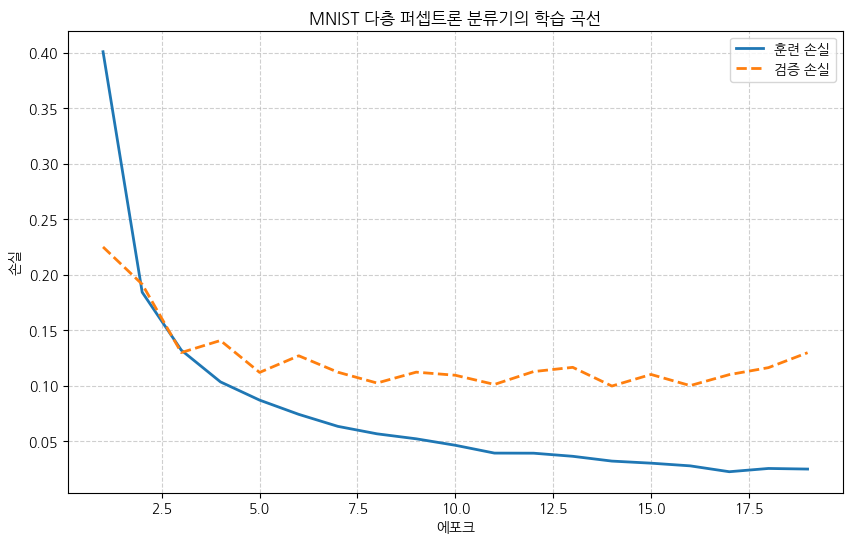

In [12]:
# 참고 - MNIST 학습 곡선 (EpochLogger 표준)
log.plot(title='MNIST 다층 퍼셉트론 분류기의 학습 곡선', y_label='손실')

## [코드 4-24] 훈련 데이터셋과 평가 데이터셋의 분류 정확도

평가 데이터로더로 분류 정확도를 계산한다. 본문은 텐서 직접 입력 형태의 `get_accuracy` 를 보여주므로 노트북에도 같은 형태를 둔다. `code_reference.common.get_accuracy()` (데이터로더 기반) 결과와도 비교한다.

In [21]:
# 코드 4-24 - 훈련 데이터셋과 평가 데이터셋의 분류 정확도

# 분류 정확도를 계산하는 함수
def get_accuracy(model, data_loader):
    model.eval()
    correct_size = 0
    sample_size = 0
    with torch.no_grad():
        # 데이터로더로부터 데이터를 받아서 분류 결과를 예측하고 정확도 계산
        for X, Y in data_loader:
            outputs = model(X)
            # 출력층의 10 개 값 중 가장 큰 값의 인덱스가 예측 결과
            predicted = outputs.argmax(dim=1)
            correct_size += (predicted == Y).sum().item()
            sample_size += X.size(0)
    return correct_size / sample_size * 100

accuracy_train = get_accuracy(model, train_loader)
accuracy_test = get_accuracy(model, test_loader)

print(f'훈련 데이터셋 분류 정확도: {accuracy_train:.2f}%')
print(f'평가 데이터셋 분류 정확도: {accuracy_test:.2f}%')

훈련 데이터셋 분류 정확도: 99.27%
평가 데이터셋 분류 정확도: 97.52%


## 참고 - 혼동 행렬 시각화 (본문 [코드 4-24] 이후 설명 대응)

본문은 정확도만으로 모델을 평가하기 어려울 때 혼동 행렬을 권한다. `common.get_confusion_matrix()` 로 10x10 혼동 행렬을 계산해 히트맵으로 그린다.

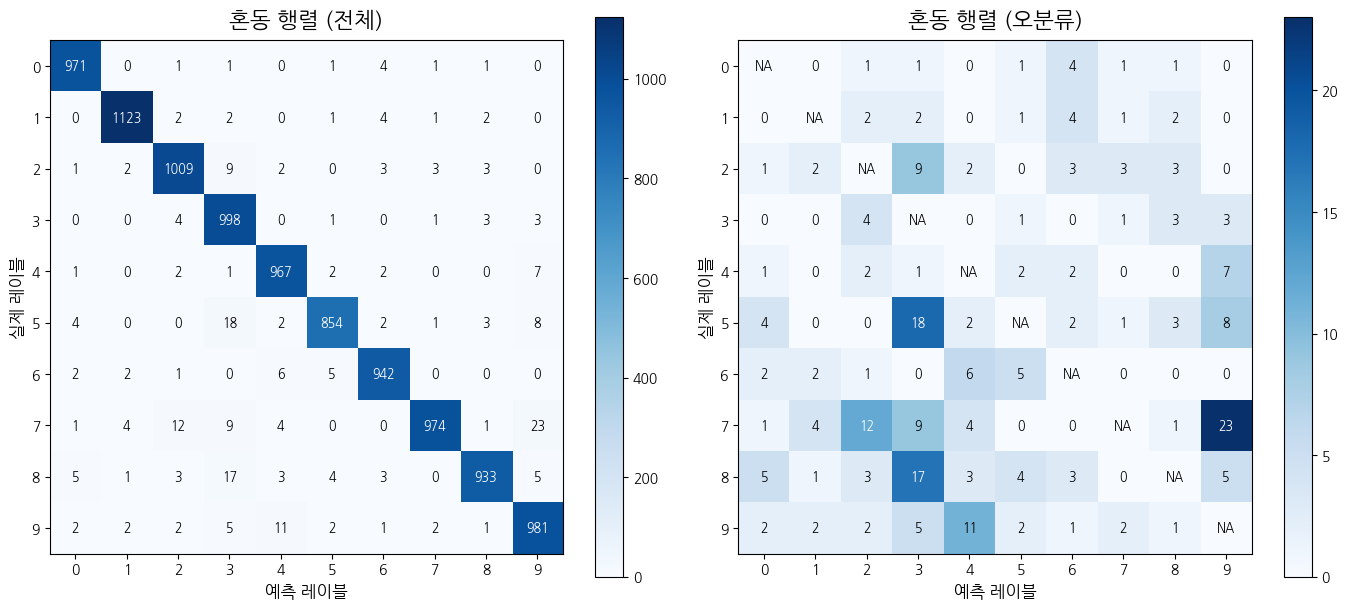

In [22]:
# 참고 - 혼동 행렬 계산 및 시각화
cm = common.get_confusion_matrix(model, test_loader, num_classes=10)
viz.plot_confusion_matrix(cm, class_names=list('0123456789'))

## 정리

- torchvision 의 `datasets.MNIST` 로 내장 데이터셋을 손쉽게 불러온다.
- 이미지 변환은 `ToTensor`(0~1 정규화, (C, H, W) 변환), `Normalize`(표준화), `Resize`(크기 조정) 를 `transforms.Compose` 로 묶어 적용한다.
- 4-2 절의 미니배치 + 조기 종료 학습 함수를 그대로 재사용해 숫자 분류기를 학습·평가한다.

> 노트북 결과는 시드 42 기준이므로 본문 수치와 다를 수 있다. (출력 수치 반영은 2 단계 작업에서 다룬다.)

## 참고 - 5장 [그림 5-2] 대응: 주요 오답 패턴의 오분류 샘플 모음

본문 5-1 절 도입은 위 혼동 행렬에서 자주 틀리는 오답 패턴을 찾아, 해당 오분류 샘플을 직접 들여다본다. 비대각 원소 중 건수가 가장 많은 네 패턴에서 오분류 샘플을 앞에서부터 4 개씩 모아 4x4 격자로 표시한다. 각 행이 한 패턴에 해당하며, 제목의 `정답 → 예측` 표기로 어떤 오분류인지 표시한다.

7 → 9 오분류: 23건
5 → 3 오분류: 18건
8 → 3 오분류: 17건
7 → 2 오분류: 12건


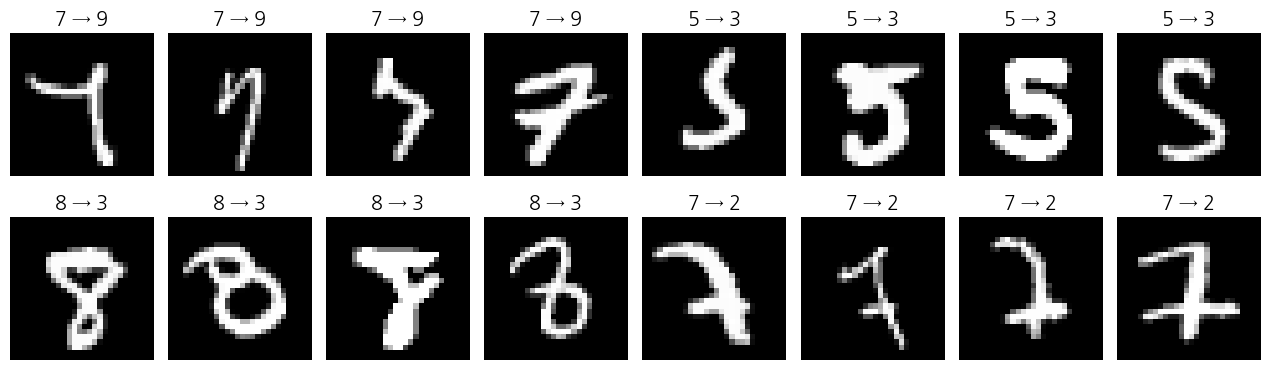

In [16]:
# 참고 - 5장 [그림 5-2] 대응: 주요 오답 패턴의 오분류 샘플 모음
# 평가 데이터셋 전체의 예측 레이블 수집 (test_loader 는 shuffle=False 라 데이터셋 순서가 유지된다)
model.eval()
pred_list = []
with torch.no_grad():
    for inputs, _ in test_loader:
        outputs = model(inputs.to(device))
        pred_list.append(outputs.argmax(dim=1).cpu())
preds = torch.cat(pred_list)                # (10000,) 예측 레이블
labels = test_set.targets                   # (10000,) 정답 레이블

# 혼동 행렬(cm)의 비대각(오분류) 원소 중 건수가 가장 많은 네 가지 오답 패턴
error_cm = cm.clone()
error_cm.fill_diagonal_(0)                  # 정답(대각 원소)을 0 으로 지워 오분류만 남김
top_values, top_indices = error_cm.flatten().topk(4)
patterns = [(int(i) // 10, int(i) % 10) for i in top_indices]
for (t, p), v in zip(patterns, top_values):
    print(f'{t} → {p} 오분류: {int(v)}건')

# 각 패턴의 오분류 샘플을 앞에서부터 4 개씩 수집
imgs, descs = [], []
for t, p in patterns:
    idxs = ((labels == t) & (preds == p)).nonzero().flatten()[:4]
    for idx in idxs:
        imgs.append(test_set.data[idx])     # 변환 전 원본 (28, 28) 이미지
        descs.append(f'{t} → {p}')
viz.plot_images(imgs, descs, images_per_row=8)

In [17]:
# 특정 오분류 패턴의 샘플 idx를 수집
def get_misclassified_indices(labels, preds, true_label, pred_label):
    """특정 오분류 패턴의 샘플 인덱스를 반환하는 함수."""
    return ((labels == true_label) & (preds == pred_label)).nonzero().flatten()
misclassified_7_to_9_idxs = get_misclassified_indices(labels, preds, 7, 9).tolist()
misclassified_5_to_3_idxs = get_misclassified_indices(labels, preds, 5, 3).tolist()
misclassified_7_to_2_idxs = get_misclassified_indices(labels, preds, 7, 2).tolist()

print(f'7 → 9 오분류 샘플 인덱스: {misclassified_7_to_9_idxs}')
print(f'5 → 3 오분류 샘플 인덱스: {misclassified_5_to_3_idxs}')
print(f'7 → 2 오분류 샘플 인덱스: {misclassified_7_to_2_idxs}')

7 → 9 오분류 샘플 인덱스: [358, 689, 726, 1194, 1328, 1496, 1522, 1721, 1941, 2024, 2070, 3225, 3333, 3376, 3451, 4027, 4102, 4578, 5600, 6599, 7902, 7915, 7927]
5 → 3 오분류 샘플 인덱스: [340, 412, 1003, 1331, 1393, 1970, 2035, 2526, 2597, 2810, 3968, 4271, 4300, 5937, 5972, 5982, 6042, 6043]
7 → 2 오분류 샘플 인덱스: [684, 1039, 1226, 1754, 1903, 2016, 2325, 4433, 4690, 9009, 9015, 9024]


In [18]:
true_9 = get_misclassified_indices(labels, preds, 9, 9).tolist()
print(true_9)

[7, 9, 12, 16, 20, 58, 62, 73, 78, 92, 99, 104, 105, 108, 113, 118, 125, 150, 151, 185, 193, 206, 209, 212, 214, 235, 241, 252, 264, 273, 274, 281, 284, 292, 315, 320, 322, 336, 359, 389, 394, 414, 417, 422, 426, 434, 448, 454, 471, 479, 481, 487, 488, 496, 501, 521, 530, 558, 560, 562, 575, 593, 598, 599, 616, 627, 630, 634, 639, 662, 671, 673, 678, 681, 706, 733, 758, 759, 773, 788, 813, 833, 862, 874, 882, 893, 906, 913, 928, 954, 962, 966, 992, 999, 1000, 1005, 1013, 1045, 1048, 1058, 1063, 1081, 1086, 1088, 1090, 1103, 1105, 1107, 1130, 1152, 1165, 1183, 1192, 1217, 1255, 1277, 1282, 1304, 1308, 1309, 1311, 1322, 1327, 1343, 1380, 1385, 1396, 1414, 1417, 1418, 1423, 1428, 1429, 1435, 1439, 1449, 1452, 1455, 1481, 1486, 1492, 1501, 1508, 1512, 1532, 1545, 1553, 1554, 1559, 1594, 1596, 1597, 1622, 1627, 1631, 1640, 1645, 1647, 1648, 1655, 1666, 1668, 1695, 1697, 1709, 1714, 1732, 1743, 1745, 1781, 1787, 1788, 1793, 1801, 1812, 1821, 1825, 1851, 1853, 1869, 1873, 1881, 1894, 1904, 19

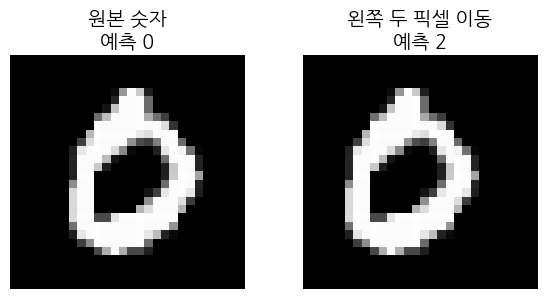

In [19]:
# 참고 - sample_0_shifted 텐서 생성 (본문 미공개 보조 코드)
# 평가 데이터셋에서 정답이 0 인 첫 번째 샘플을 찾는다
for img, label in test_set:
    if label == 0:
        sample_0 = img
        break

# 왼쪽으로 두 픽셀 이동 (오른쪽 두 열은 배경값 -1.0 으로 채움)
sample_0_shifted = torch.full_like(sample_0, fill_value=-1.0)
sample_0_shifted[..., :-2] = sample_0[..., 2:]

# 원본 vs 이동본 비교 시각화
viz.plot_images(
    [sample_0, sample_0_shifted],
    ['원본 숫자\n예측 0', '왼쪽 두 픽셀 이동\n예측 2'],
    images_per_row=2,
    figsize=(6, 3),
)

In [20]:
model.eval()
with torch.no_grad():    
    output = model(sample_0_shifted.unsqueeze(0))
    predicted = output.argmax(dim=1).item()

print(f'예측: {predicted}')                            # 출력값: 0
print(f'숫자 0 의 로짓: {output[0][0].item():.4f}')
print(f'숫자 2 의 로짓: {output[0][2].item():.4f}')

예측: 2
숫자 0 의 로짓: 1.8539
숫자 2 의 로짓: 4.2811
